# Reading DJI parts listings without inventing compatibility

![Title-family counts in the frozen 30-listing supplier sample.](https://reboot-hub.github.io/dji-drone-parts-reference/datasets/listing-sample-20261003/title-family-counts.png)

This illustrated companion uses the existing [Kaggle release](https://www.kaggle.com/datasets/reboothub/dji-oem-pulled-parts-listing-sample-2026), observed **3 October 2026**: 30 listings, 30 matched public source checks, no duplicate listing IDs or URLs. One row is a supplier listing, not a physical part, sale, stock count or validated fit relationship.

## Goal
Learn how to check a dated catalog sample, preserve its grain, and distinguish title labels from engineering evidence. The figures are saved so readers can inspect them without connecting a runtime.

## Setup and boundaries

Pandas and Matplotlib are available in a normal Colab Python runtime. Local CSVs are used only if they match the release fingerprints; otherwise the loader uses the public GitHub release folder. Both inputs are checked before use. No credentials or live retailer crawl are needed.

Selection: first 30 records returned in supplier collection order, not random, exhaustive or representative. OEM-pulled is a supplier title phrase, not an independent authentication result. No compatibility, certification, current-stock, price, sales or market-demand claim is supported. Source publication dates are not manufacture, launch or first-sale dates. Reboot Hub publishes the original first-party sample and is not officially authorized by DJI.

## Steps

### 1. Load and fingerprint the frozen inputs

In [1]:
from pathlib import Path
from urllib.request import urlopen
from io import BytesIO
import hashlib, base64
from html import escape
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

RAW_BASE = 'https://raw.githubusercontent.com/Reboot-Hub/dji-drone-parts-reference/344c0b71d465b87b4fe06be5b0a188ec12eb6c02/datasets/listing-sample-20261003/'
PUBLISHED_IMAGE_BASE = 'https://reboot-hub.github.io/dji-drone-parts-reference/datasets/listing-sample-20261003/'
EXPECTED_SHA256 = {'parts_listing_reference_20261003.csv': '686f75ac13d01dfaf921cc3abdaadc264ea3f699fe5d0fb0ef902b898c64d5df', 'source_checks_20261003.csv': 'c2af9873c381850e49eb1041d1edf9773870d7c0ed9e76d44893be9303731c25'}

def load_frozen_csv(filename):
    local = Path(filename)
    payload = local.read_bytes() if local.exists() else urlopen(RAW_BASE + filename, timeout=30).read()
    if hashlib.sha256(payload).hexdigest() != EXPECTED_SHA256[filename]:
        raise ValueError('Input differs from the dated release: ' + filename)
    return pd.read_csv(BytesIO(payload), dtype={'product_id': str}, keep_default_na=False)

data = load_frozen_csv('parts_listing_reference_20261003.csv')
checks = load_frozen_csv('source_checks_20261003.csv')
plt.rcParams.update({'font.size': 11, 'font.family': 'DejaVu Sans', 'axes.spines.top': False, 'axes.spines.right': False})

def display_plot(fig, alt, filename):
    fig.text(.02,.02,'Source: Reboot Hub | observed 3 October 2026 | selected supplier listing sample',fontsize=9,color='#536173')
    buf = BytesIO()
    fig.savefig(buf,format='png',dpi=150,bbox_inches='tight',facecolor='white')
    payload = buf.getvalue()
    encoded = base64.b64encode(payload).decode('ascii')
    display({'image/png': encoded, 'text/html': '<figure><img src="data:image/png;base64,'+encoded+'" alt="'+escape(alt,quote=True)+'" style="max-width:100%;height:auto"><figcaption>'+escape(alt)+' <a href="'+PUBLISHED_IMAGE_BASE+filename+'">Published release PNG</a></figcaption></figure>', 'text/plain': alt},raw=True)
    plt.close(fig)

display(data[['product_id','listing_title','title_family_label']].head())

,product_id,listing_title,title_family_label
0,8934584582321,DJI Goggles Integra Middle Frame - OEM-pulled,Goggles
1,9133306413233,DJI Air 3S Gimbal Vibration Absorbing Board - ...,Air
2,9104352182449,DJI Goggles 2 I/O Port Board Assembly - OEM-pu...,Goggles
3,9067558928561,DJI Air 3S Motherboard - OEM-pulled,Air
4,8934592970929,DJI Matrice 300/350 Series Downward Gimbal PSD...,Matrice


### 2. Validate the listing grain and source join

A source check records observation-time HTTP and H1 matching. It does not guarantee future availability or validate the physical component.

In [2]:
assert len(data) == 30
assert data.product_id.is_unique and data.source_url.is_unique
assert data[['product_id','listing_title','source_url']].ne('').all().all()
joined = data.merge(checks, on=['product_id','source_url'], how='left', validate='one_to_one')
assert len(joined) == len(data)
assert joined.http_status.eq(200).all()
assert joined.visible_title_matches.eq(True).all()
assert data.independent_compatibility_test.eq('not_performed').all()
display(pd.DataFrame({'check':['listing rows','duplicate IDs','unmatched source checks','independent compatibility tests'], 'result':[len(data),int(data.product_id.duplicated().sum()),int(joined.http_status.isna().sum()),0]}))

,check,result
0,listing rows,30
1,duplicate IDs,0
2,unmatched source checks,0
3,independent compatibility tests,0


### 3. Count the lexical title groups

These categories come from matching words in listing titles. They are not a parts interchangeability chart.

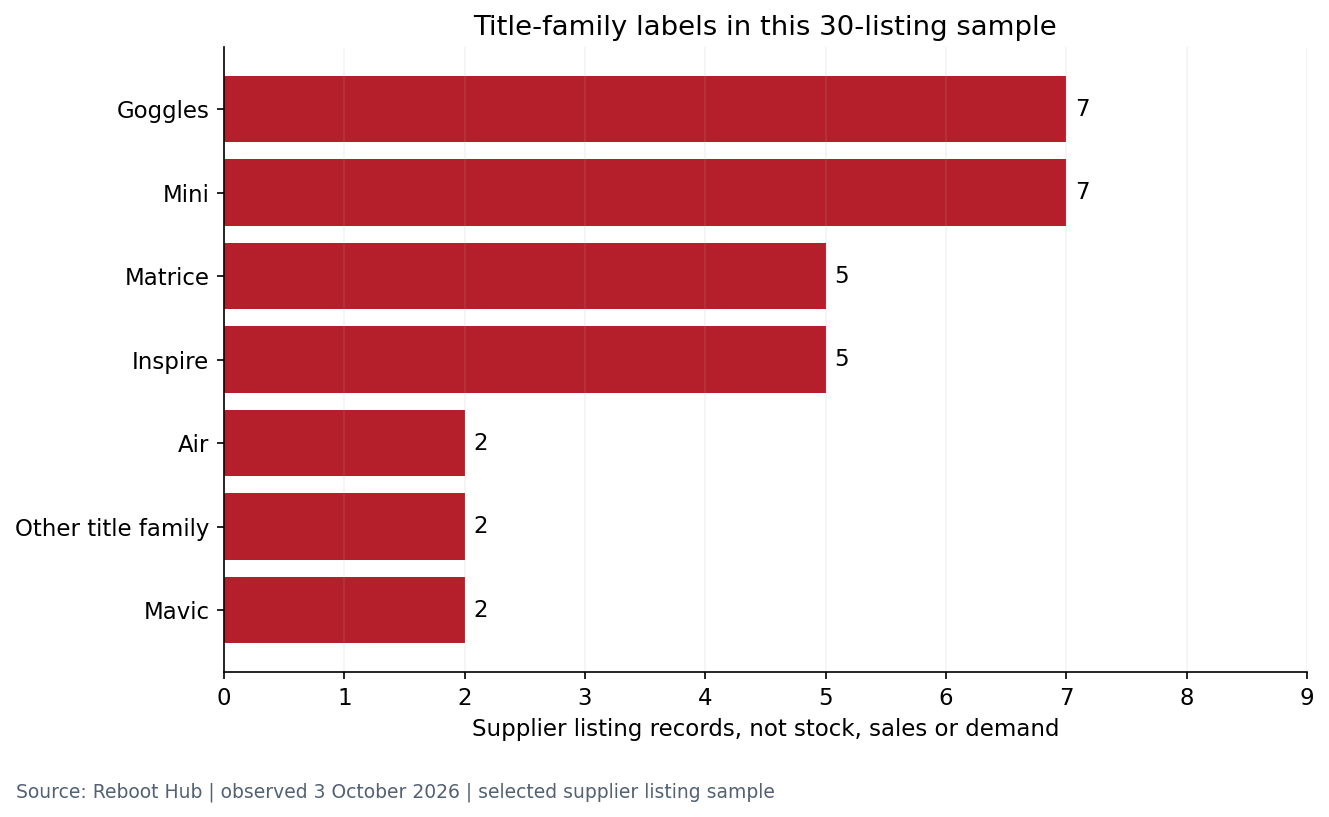

In [3]:
counts = data.title_family_label.value_counts().sort_values()
assert int(counts.sum()) == len(data)
fig, ax = plt.subplots(figsize=(9,5.5))
bars = ax.barh(counts.index,counts.values,color='#b51f2b')
ax.bar_label(bars,padding=4)
ax.set_title('Title-family labels in this 30-listing sample')
ax.set_xlabel('Supplier listing records, not stock, sales or demand')
ax.set_xlim(0,int(counts.max())+2)
ax.grid(axis='x',alpha=.15)
fig.tight_layout(rect=[0,.06,1,1])
display_plot(fig,'Goggles and Mini each have seven listing records, Matrice and Inspire five each, and Air, Mavic and Other two each. Lexical title labels do not establish model-to-part compatibility.','title-family-counts.png')

### 4. Separate publication metadata from the observation date

The entire sample was captured on 3 October 2026. The different months below describe source publication timestamps, not different collection dates, sales counts or a demand trend.

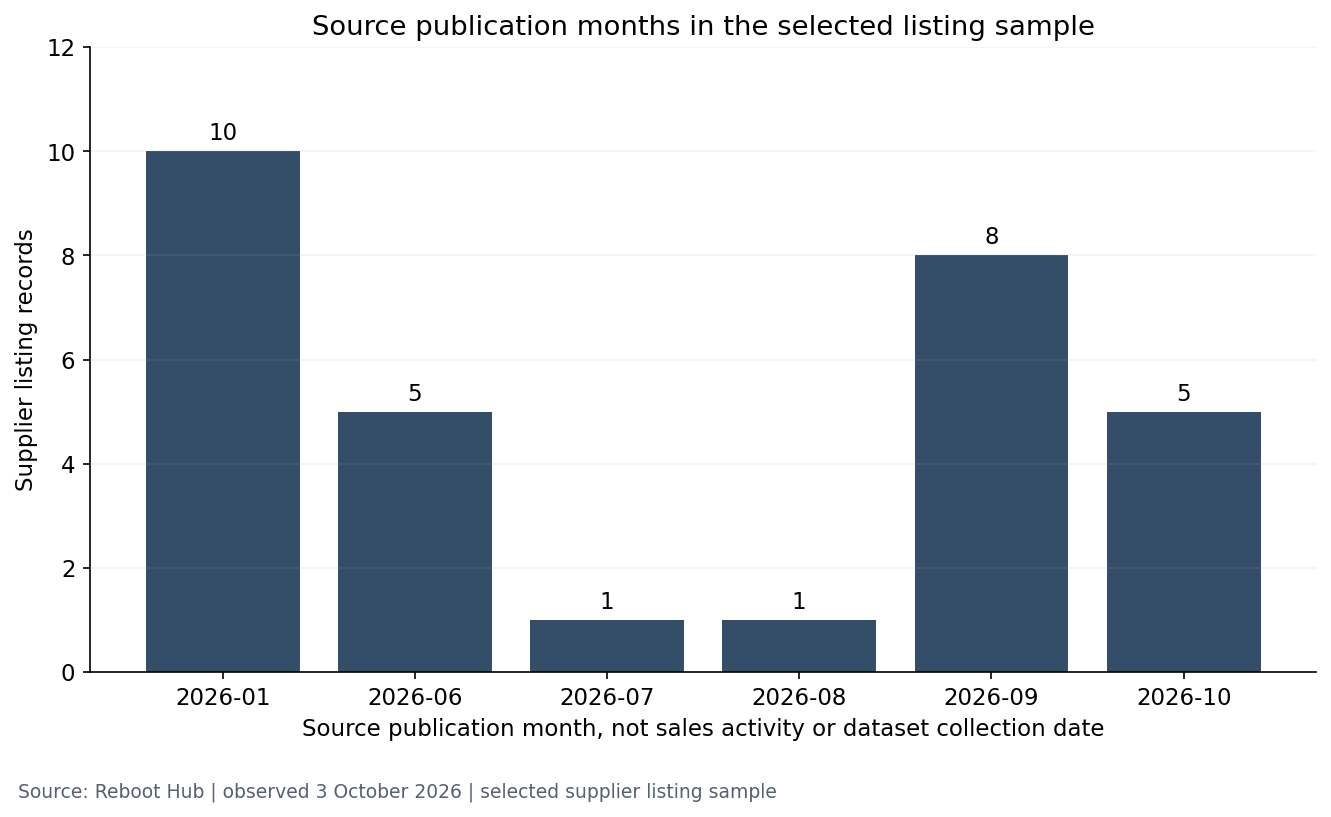

In [4]:
months = data.source_published_at.str.slice(0,7).value_counts().sort_index()
assert int(months.sum()) == len(data)
fig, ax = plt.subplots(figsize=(9,5.5))
bars = ax.bar(months.index,months.values,color='#344d69')
ax.bar_label(bars,padding=3)
ax.set_title('Source publication months in the selected listing sample')
ax.set_ylabel('Supplier listing records')
ax.set_xlabel('Source publication month, not sales activity or dataset collection date')
ax.set_ylim(0,int(months.max())+2)
ax.grid(axis='y',alpha=.15)
fig.tight_layout(rect=[0,.06,1,1])
display_plot(fig,'Publication months recorded by one supplier: January ten, June five, July one, August one, September eight and October five. This partial non-random sample does not establish a market or launch trend.','source-publication-months.png')

## Checks and next steps

A title may identify the supplier's declared device family and condition phrase; it does not settle exact version, connector, mounting position, included pieces or installation suitability. Use the current [parts buying evidence guide](https://reboot-hub.com/pages/dji-parts-accessories-buying-guide) and exact row-level source URL for those questions. The [Enterprise B2B scope](https://reboot-hub.com/pages/bulk-purchase-b2b-section) is a supplier service reference, not an independent test.

The documented checks establish 30 unique listings, a one-to-one source-check join and zero physical compatibility tests. A later comparable observation would be needed for any catalog-change analysis; these figures alone cannot show a market trend.

Original compilation, code and figures: Reboot Hub, CC BY 4.0. Dataset release v1.0.0, observed 3 October 2026. Product photographs and trademarks are not relicensed. This is another access format for the same dataset, not a new independent source or editorial endorsement.